In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
df = pd.read_csv(r'healthcare_dataset.csv')
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Shape: (55500, 17)
Columns: ['Name', 'Age', 'Gender', 'Blood Type', 'Medical Condition', 'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider', 'Billing Amount', 'Room Number', 'Admission Type', 'Discharge Date', 'Medication', 'Test Results', 'Length os Stay', 'Age Group']


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results,Length os Stay,Age Group
0,Bobby JacksOn,30,Male,B-,Cancer,31-01-2024,Matthew Smith,Sons and Miller,Blue Cross,"₹ 18,856.28",328,Urgent,02-02-2024,Paracetamol,Normal,2,Adult
1,LesLie TErRy,62,Male,A+,Obesity,20-08-2019,Samantha Davies,Kim Inc,Medicare,"₹ 33,643.33",265,Emergency,26-08-2019,Ibuprofen,Inconclusive,6,Senior
2,DaNnY sMitH,76,Female,A-,Obesity,22-09-2022,Tiffany Mitchell,Cook PLC,Aetna,"₹ 27,955.10",205,Emergency,07-10-2022,Aspirin,Normal,15,Senior
3,andrEw waTtS,28,Female,O+,Diabetes,18-11-2020,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,"₹ 37,909.78",450,Elective,18-12-2020,Ibuprofen,Abnormal,30,Adult
4,adrIENNE bEll,43,Female,AB+,Cancer,19-09-2022,Kathleen Hanna,White-White,Aetna,"₹ 14,238.32",458,Urgent,09-10-2022,Penicillin,Abnormal,20,Adult


In [4]:
print("Dataset Info:")
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Name                55500 non-null  object
 1   Age                 55500 non-null  int64 
 2   Gender              55500 non-null  object
 3   Blood Type          55500 non-null  object
 4   Medical Condition   55500 non-null  object
 5   Date of Admission   55500 non-null  object
 6   Doctor              55500 non-null  object
 7   Hospital            55500 non-null  object
 8   Insurance Provider  55500 non-null  object
 9   Billing Amount      55500 non-null  object
 10  Room Number         55500 non-null  int64 
 11  Admission Type      55500 non-null  object
 12  Discharge Date      55500 non-null  object
 13  Medication          55500 non-null  object
 14  Test Results        55500 non-null  object
 15  Length os Stay      55500 non-null  int64 
 16  Age Grou

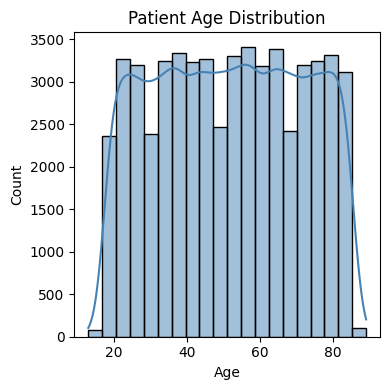

In [27]:
plt.figure(figsize=(4,4))
sns.histplot(df['Age'], bins=20, kde=True, color='steelblue')
plt.title('Patient Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [7]:
# Clean Billing Amount column
df['Billing Amount'] = df['Billing Amount'].astype(str)
df['Billing Amount'] = df['Billing Amount'].str.replace('₹', '', regex=False)
df['Billing Amount'] = df['Billing Amount'].str.replace(',', '', regex=False)
df['Billing Amount'] = df['Billing Amount'].str.strip()
df['Billing Amount'] = pd.to_numeric(df['Billing Amount'], errors='coerce')

print("Billing Amount cleaned!")
print(df['Billing Amount'].dtype)
print(df['Billing Amount'].head())

Billing Amount cleaned!
float64
0    18856.28
1    33643.33
2    27955.10
3    37909.78
4    14238.32
Name: Billing Amount, dtype: float64


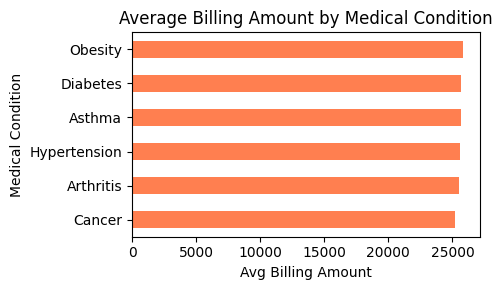

In [20]:
plt.figure(figsize=(5,3))
df.groupby('Medical Condition')['Billing Amount'].mean().sort_values().plot(kind='barh', color='coral')
plt.title('Average Billing Amount by Medical Condition')
plt.xlabel('Avg Billing Amount')
plt.tight_layout()
plt.show()

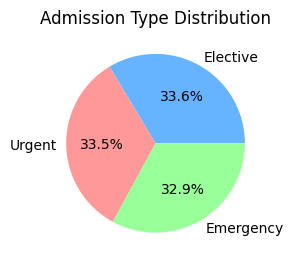

In [21]:
plt.figure(figsize=(3,3))
df['Admission Type'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['#66b3ff','#ff9999','#99ff99'])
plt.title('Admission Type Distribution')
plt.ylabel('')
plt.tight_layout()
plt.show()

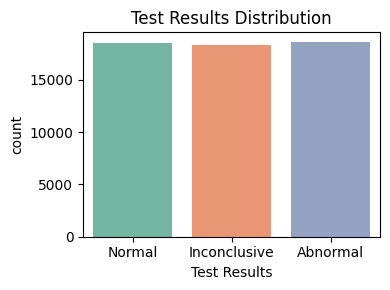

In [25]:
plt.figure(figsize=(4,3))
sns.countplot(data=df, x='Test Results', hue='Test Results', palette='Set2', legend=False)
plt.title('Test Results Distribution')
plt.tight_layout()
plt.show()

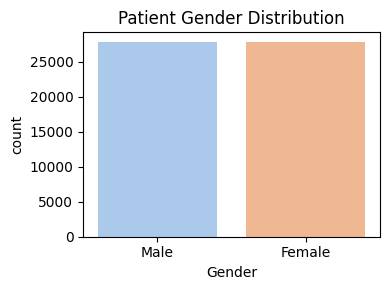

In [26]:
plt.figure(figsize=(4,3))
sns.countplot(data=df, x='Gender', hue='Gender', palette='pastel', legend=False)
plt.title('Patient Gender Distribution')
plt.tight_layout()
plt.show()